# Analise de Dados: Uso de Cosmeticos — Causas e Consequencias
**Pesquisadora:** Nathalia Kleber Pereira — FCF-USP  
**Objetivo:** Investigar o comportamento de consumidores brasileiros no uso de skincare, praticas de automedicacao e adesao a tendencias sem respaldo tecnico.  
**n = 124 respondentes**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, r2_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#6C63FF','#FF6584','#43B89C','#FFC75F','#845EC2','#FF9671','#0081CF','#D65DB1']
sns.set_palette(PALETTE)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [2]:
FILE = '/mnt/user-data/uploads/Uso_de_cosm\u00e9ticos_causas_e_consequ\u00eancias___respostas__-_Respostas_ao_formul\u00e1rio_1__1_.csv'
df_raw = pd.read_csv(FILE)

COL = {
    df_raw.columns[0]:  'timestamp',
    df_raw.columns[1]:  'tcle',
    df_raw.columns[2]:  'genero',
    df_raw.columns[3]:  'nome',
    df_raw.columns[4]:  'email',
    df_raw.columns[5]:  'idade',
    df_raw.columns[6]:  'escolaridade',
    df_raw.columns[7]:  'influencia_compra',
    df_raw.columns[8]:  'conhece_efeitos',
    df_raw.columns[9]:  'ativos_usados',
    df_raw.columns[10]: 'qtd_produto_ideal',
    df_raw.columns[11]: 'sobreposicao_ativo',
    df_raw.columns[12]: 'metodo_nao_convencional',
    df_raw.columns[13]: 'num_produtos',
    df_raw.columns[14]: 'motivacao',
    df_raw.columns[15]: 'crenca_natural',
    df_raw.columns[16]: 'sintomas_12m',
    df_raw.columns[17]: 'resposta_sintoma',
    df_raw.columns[18]: 'tempo_recuperacao',
    df_raw.columns[19]: 'combinacao_ativos',
    df_raw.columns[20]: 'diagnostico_medico',
    df_raw.columns[21]: 'automedicacao_6m',
}
df = df_raw.rename(columns=COL).drop(columns=['tcle','nome','email','timestamp'])
df = df[df['genero'].notna()].copy()

# Ordinais
df['num_produtos_ord'] = df['num_produtos'].map({
    'Nenhum': 0, '1 a 2 produtos': 1, '3 a 5 produtos': 2,
    '6 a 8 produtos': 3, '9 ou mais produtos': 4})

df['escolaridade_ord'] = df['escolaridade'].map({
    'Ensino M\u00e9dio Incompleto/Completo': 1,
    'Ensino Superior Incompleto': 2,
    'Ensino Superior Completo': 3,
    'P\u00f3s-gradua\u00e7\u00e3o (Especializa\u00e7\u00e3o; Mestrado; Doutorado)': 4})

df['tempo_rec_ord'] = df['tempo_recuperacao'].map({
    'Nunca tive uma rea\u00e7\u00e3o vis\u00edvel': 0,
    'Menos de 24 horas': 1, '1 a 3 dias': 2, '4 a 7 dias': 3,
    'Mais de uma semana': 4})

# Binarios
df['automedicacao_bin'] = (df['automedicacao_6m'] == 'Sim').astype(int)
df['sobreposicao_bin']  = (df['sobreposicao_ativo'] == 'Sim').astype(int)
df['conhece_bin']       = (df['conhece_efeitos'] == 'Sim').astype(int)
df['teve_sintoma']      = (~df['sintomas_12m'].str.contains('N\u00e3o apresentei', na=True)).astype(int)
df['uso_alto']          = (df['num_produtos_ord'] >= 3).astype(int)

df['n_ativos'] = df['ativos_usados'].fillna('').apply(
    lambda x: len([i for i in x.split(',')
                   if i.strip() and i.strip() != 'Nenhuma das anteriores']))

print(f"Dataset limpo: {df.shape[0]} respondentes, {df.shape[1]} variaveis")
df[['genero','idade','escolaridade','num_produtos','automedicacao_6m']].head()


Dataset limpo: 122 respondentes, 27 variaveis


,genero,idade,escolaridade,num_produtos,automedicacao_6m
1,Feminino,18-24 anos,Ensino Superior Incompleto,1 a 2 produtos,Não
2,Masculino,25-34 anos,Ensino Superior Incompleto,3 a 5 produtos,Sim
3,Masculino,18-24 anos,Ensino Superior Incompleto,6 a 8 produtos,Sim
4,Feminino,18-24 anos,Ensino Superior Incompleto,1 a 2 produtos,Sim
5,Feminino,18-24 anos,Ensino Superior Incompleto,3 a 5 produtos,Sim


## 1. Perfil Demografico dos Respondentes

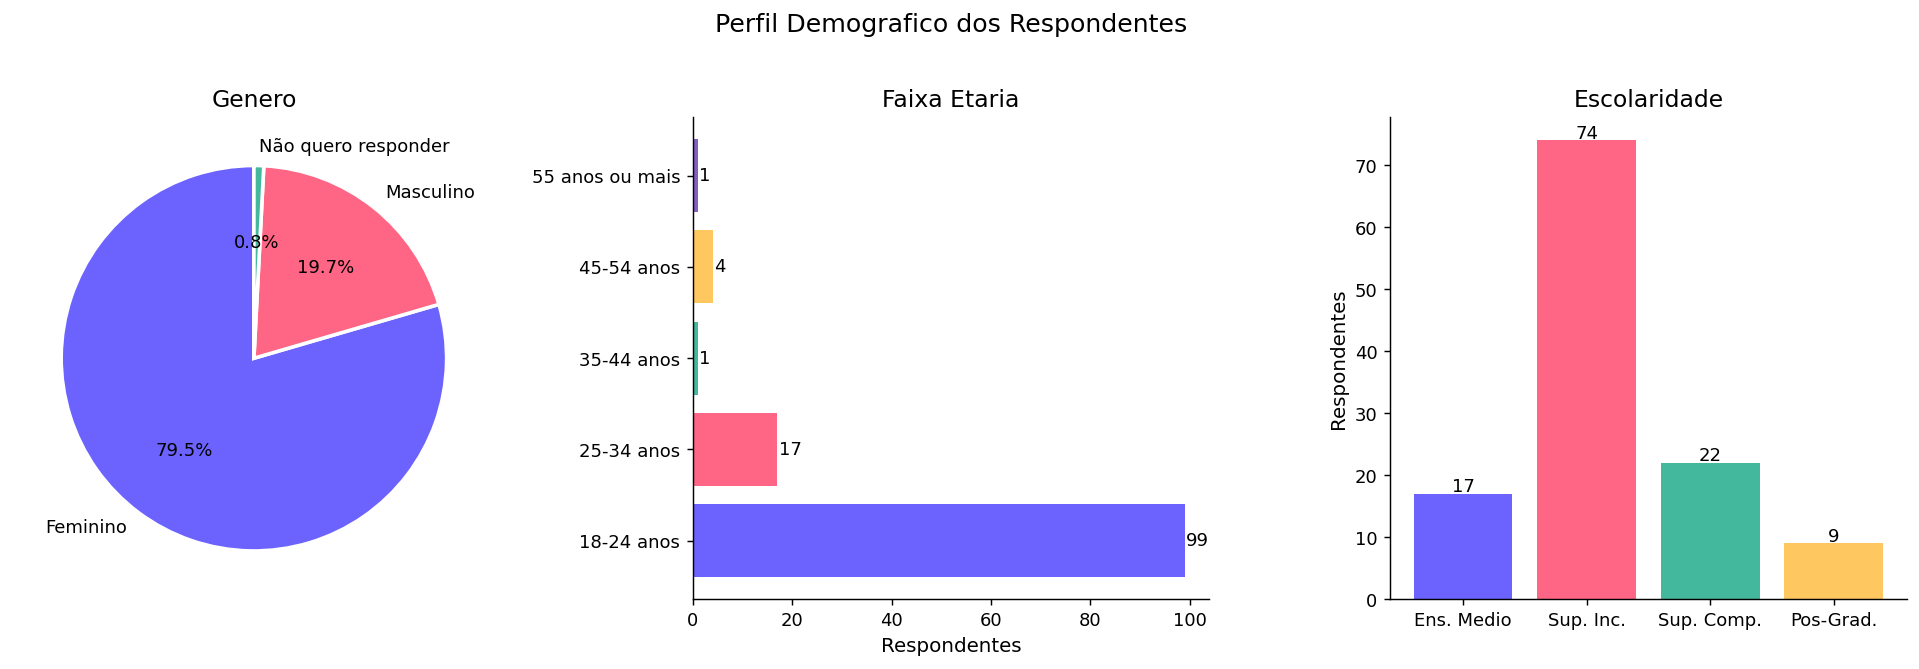

INSIGHTS:
  - Amostra majoritariamente feminina (80%)
  - Faixa etaria dominante: 18-24 anos (99 respondentes)
  - 86% tem pelo menos ensino superior incompleto


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vc_gen = df['genero'].value_counts()
axes[0].pie(vc_gen, labels=vc_gen.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Genero')

ordem_idade = ['18-24 anos','25-34 anos','35-44 anos','45-54 anos','55 anos ou mais']
vc_idade = df['idade'].value_counts().reindex(ordem_idade).dropna()
bars = axes[1].barh(vc_idade.index, vc_idade.values, color=PALETTE)
axes[1].set_xlabel('Respondentes')
axes[1].set_title('Faixa Etaria')
for bar, v in zip(bars, vc_idade.values):
    axes[1].text(v+0.3, bar.get_y()+bar.get_height()/2, str(int(v)), va='center', fontsize=10)

labels_esc = ['Ens. Medio','Sup. Inc.','Sup. Comp.','Pos-Grad.']
vc_esc = [df['escolaridade_ord'].value_counts().get(i,0) for i in [1,2,3,4]]
bars2 = axes[2].bar(labels_esc, vc_esc, color=PALETTE)
axes[2].set_ylabel('Respondentes')
axes[2].set_title('Escolaridade')
for bar, v in zip(bars2, vc_esc):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.3, str(int(v)), ha='center', fontsize=10)

plt.suptitle('Perfil Demografico dos Respondentes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

total = len(df)
fem_pct = vc_gen.get('Feminino',0)/total*100
print("INSIGHTS:")
print(f"  - Amostra majoritariamente feminina ({fem_pct:.0f}%)")
print(f"  - Faixa etaria dominante: {vc_idade.idxmax()} ({int(vc_idade.max())} respondentes)")
sup_pct = (df['escolaridade_ord']>=2).sum()/total*100
print(f"  - {sup_pct:.0f}% tem pelo menos ensino superior incompleto")


## 2. Rotina de Skincare e Uso de Produtos

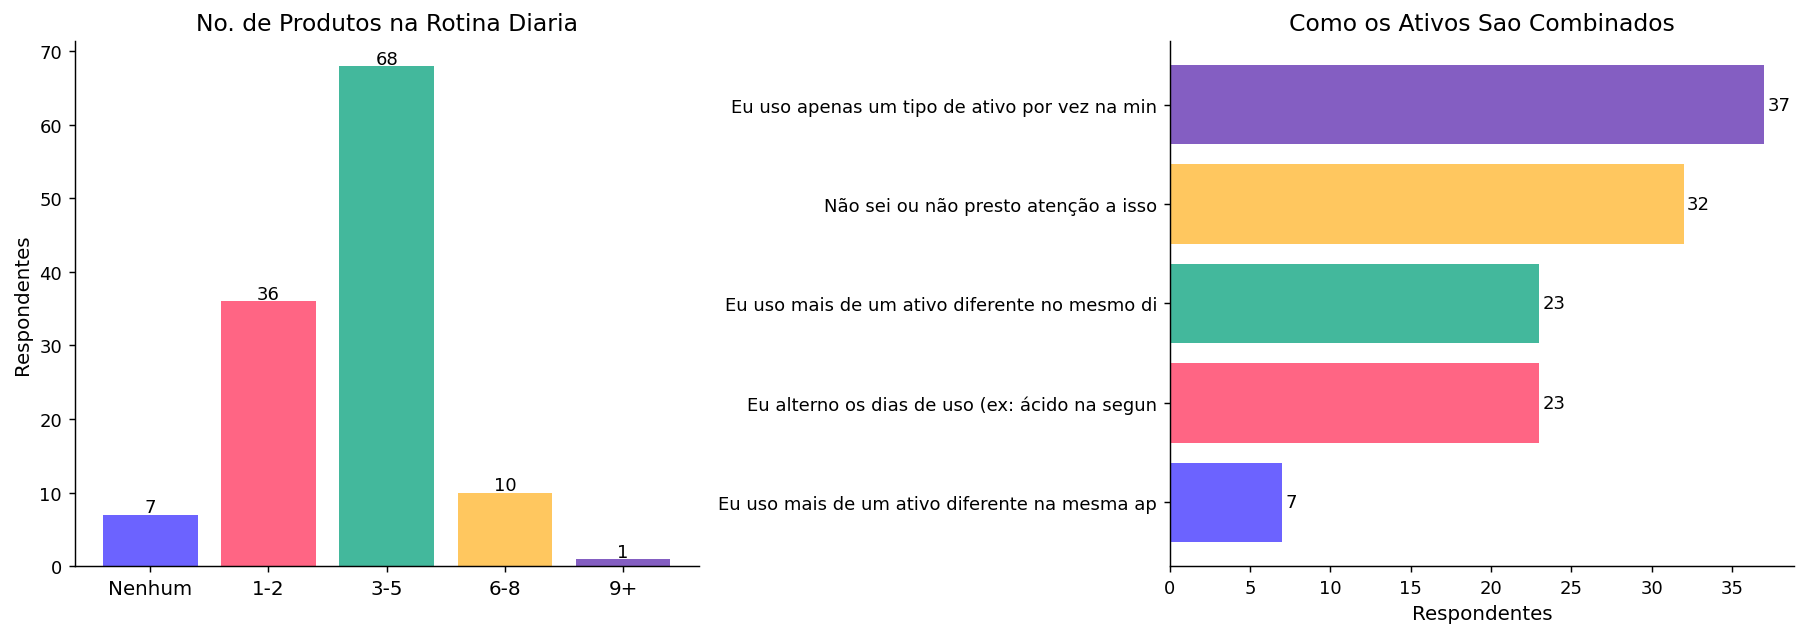

INSIGHTS:
  - 56% usam 3-5 produtos diariamente
  - 9% usam 6 ou mais produtos
  - 32 pessoas nao sabem como combinam seus ativos


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem_p = ['Nenhum','1 a 2 produtos','3 a 5 produtos','6 a 8 produtos','9 ou mais produtos']
vc_p = df['num_produtos'].value_counts().reindex(ordem_p).dropna()
bars = axes[0].bar(range(len(vc_p)), vc_p.values, color=PALETTE[:len(vc_p)])
axes[0].set_xticks(range(len(vc_p)))
axes[0].set_xticklabels(['Nenhum','1-2','3-5','6-8','9+'], fontsize=11)
axes[0].set_title('No. de Produtos na Rotina Diaria')
axes[0].set_ylabel('Respondentes')
for bar, v in zip(bars, vc_p.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, str(int(v)), ha='center')

vc_comb = df['combinacao_ativos'].value_counts()
labels_c = [l[:45] for l in vc_comb.index[:5]]
axes[1].barh(labels_c[::-1], vc_comb.values[:5][::-1], color=PALETTE[:5])
axes[1].set_title('Como os Ativos Sao Combinados')
axes[1].set_xlabel('Respondentes')
for i, v in enumerate(vc_comb.values[:5][::-1]):
    axes[1].text(v+0.2, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

p35 = vc_p.get('3 a 5 produtos',0)/len(df)*100
p6m = (df['num_produtos_ord']>=3).sum()/len(df)*100
n_ns = df['combinacao_ativos'].str.contains('sei', na=False, case=False).sum()
print("INSIGHTS:")
print(f"  - {p35:.0f}% usam 3-5 produtos diariamente")
print(f"  - {p6m:.0f}% usam 6 ou mais produtos")
print(f"  - {n_ns} pessoas nao sabem como combinam seus ativos")


## 3. Ativos Dermatologicos Mais Utilizados

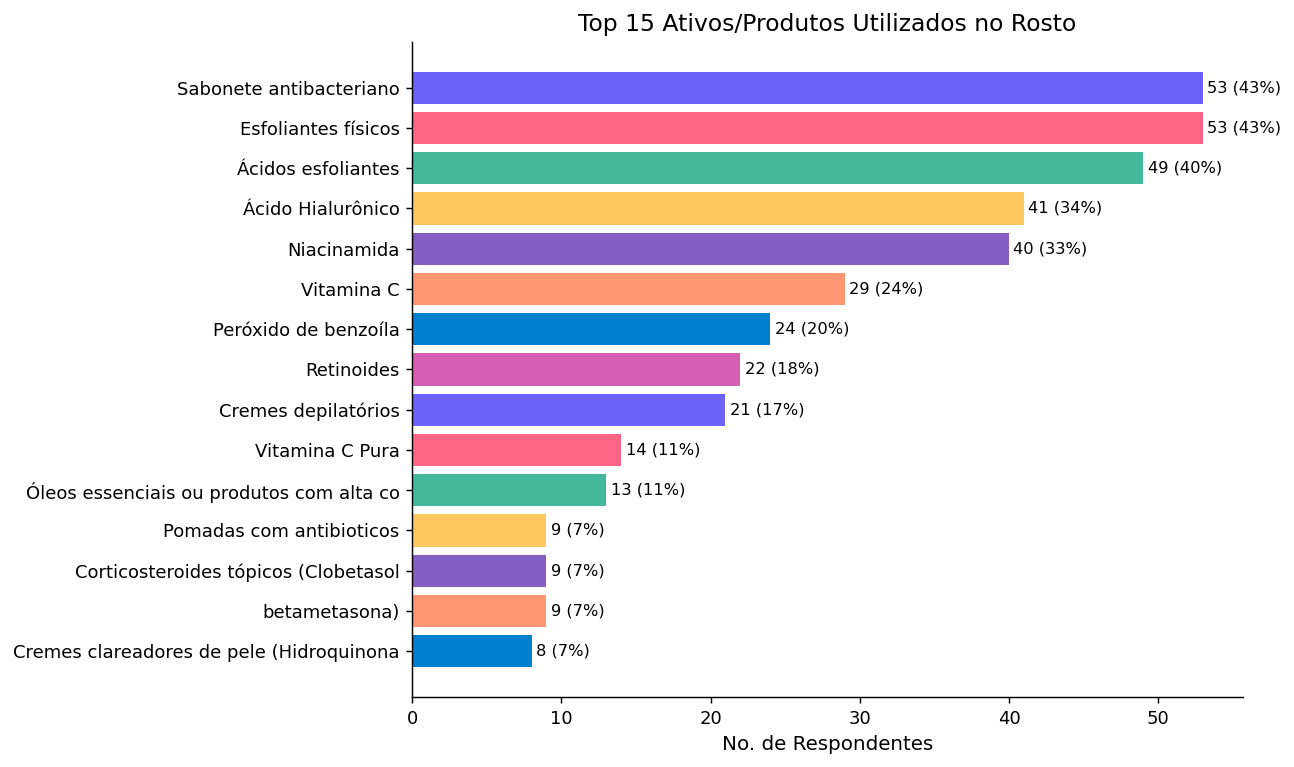

TOP 5 ATIVOS:
  - Sabonete antibacteriano: 53 (43%)
  - Esfoliantes físicos (cremes com grânulos; esponjas ): 53 (43%)
  - Ácidos esfoliantes (Glicólico; Salicilico; Mandélico; etc): 49 (40%)
  - Ácido Hialurônico: 41 (34%)
  - Niacinamida: 40 (33%)

  - Media de 3.4 ativos por respondente
  - 53 respondentes (43%) usam 4+ ativos


In [5]:
ativos_list = []
for row in df['ativos_usados'].dropna():
    for a in row.split(','):
        a = a.strip()
        if a and a != 'Nenhuma das anteriores':
            ativos_list.append(a)

ativo_count = Counter(ativos_list)
ativo_df = pd.DataFrame(ativo_count.most_common(15), columns=['Ativo','Contagem'])
ativo_df['Ativo_curto'] = ativo_df['Ativo'].str.replace(r'\s*\(.*?\)', '', regex=True).str[:40]

fig, ax = plt.subplots(figsize=(10, 6))
cores = (PALETTE * 3)[:15]
ax.barh(ativo_df['Ativo_curto'][::-1], ativo_df['Contagem'][::-1], color=cores[::-1])
ax.set_title('Top 15 Ativos/Produtos Utilizados no Rosto', fontsize=13)
ax.set_xlabel('No. de Respondentes')
for bar, v in zip(ax.patches, ativo_df['Contagem'][::-1]):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/len(df)*100:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("TOP 5 ATIVOS:")
for ativo, cnt in ativo_count.most_common(5):
    pct = cnt/len(df)*100
    print(f"  - {ativo[:60]}: {cnt} ({pct:.0f}%)")
media_at = df['n_ativos'].mean()
n_4plus = (df['n_ativos']>=4).sum()
print(f"\n  - Media de {media_at:.1f} ativos por respondente")
print(f"  - {n_4plus} respondentes ({n_4plus/len(df)*100:.0f}%) usam 4+ ativos")


## 4. Reacoes Adversas e Sintomas nos Ultimos 12 Meses

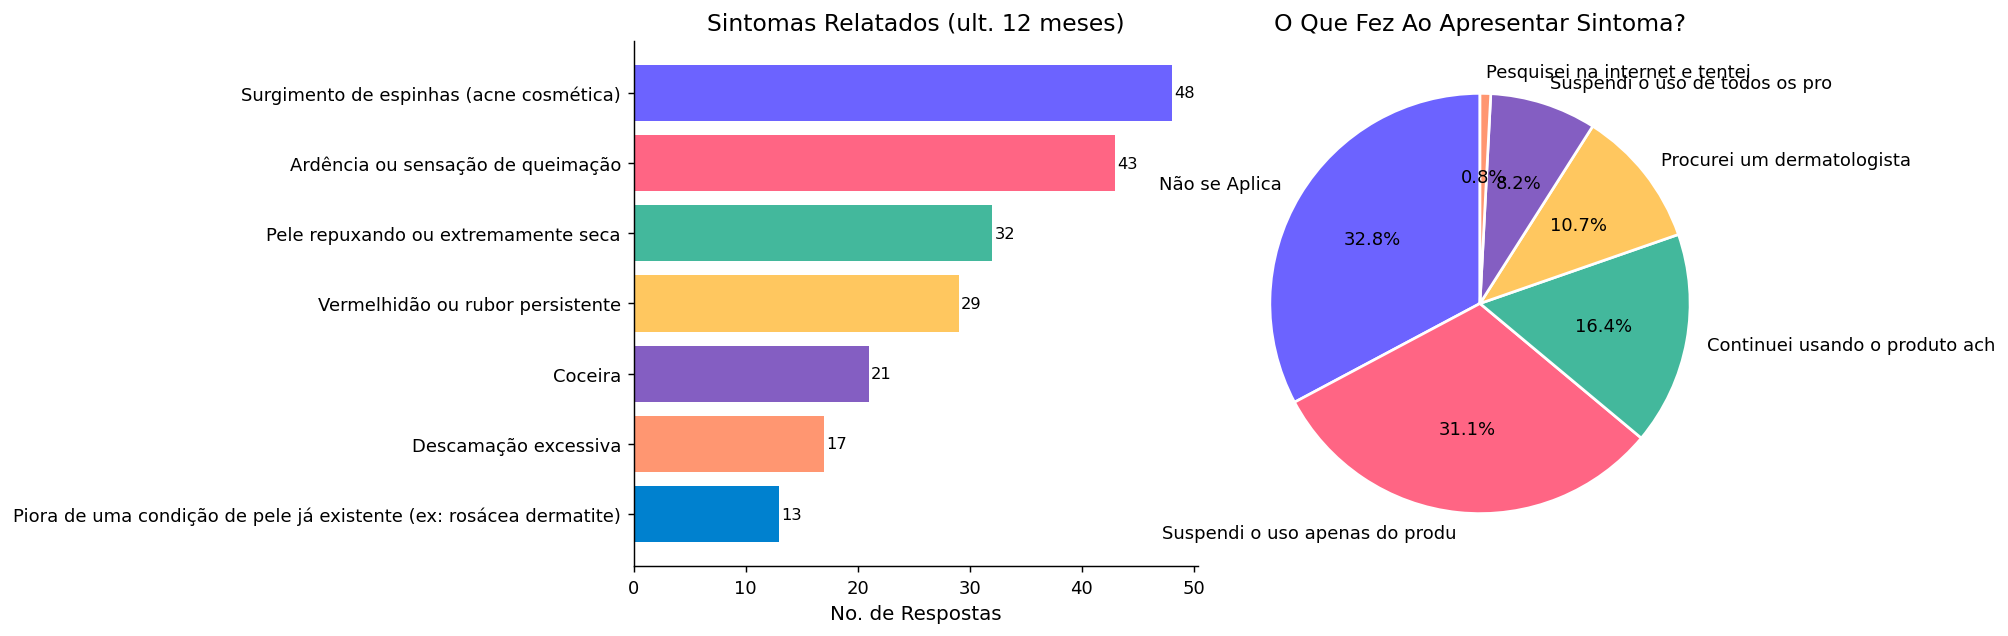

INSIGHTS:
  - 66% tiveram alguma reacao adversa nos ultimos 12 meses
  - Sintoma mais comum: Surgimento de espinhas (acne cosmética)
  - ALERTA: 20 pessoas (16%) continuaram usando mesmo com sintomas


In [6]:
sintomas_list = []
for row in df['sintomas_12m'].dropna():
    for s in row.split(','):
        s = s.strip()
        if s and 'apresentei' not in s.lower():
            sintomas_list.append(s)

sint_count = Counter(sintomas_list)
sint_df = pd.DataFrame(sint_count.most_common(), columns=['Sintoma','Contagem'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cores_s = (PALETTE * 2)[:len(sint_df)]
axes[0].barh(sint_df['Sintoma'][::-1], sint_df['Contagem'][::-1], color=cores_s[::-1])
axes[0].set_title('Sintomas Relatados (ult. 12 meses)')
axes[0].set_xlabel('No. de Respostas')
for i, v in enumerate(sint_df['Contagem'][::-1]):
    axes[0].text(v+0.2, i, str(int(v)), va='center', fontsize=9)

vc_resp = df['resposta_sintoma'].value_counts()
short_labels = {k: k[:30] for k in vc_resp.index}
vc_clean = {short_labels[k]: v for k, v in vc_resp.items()}
axes[1].pie(vc_clean.values(), labels=vc_clean.keys(), autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('O Que Fez Ao Apresentar Sintoma?')

plt.tight_layout()
plt.show()

teve_pct = df['teve_sintoma'].mean()*100
mask_cont = df['resposta_sintoma'].str.contains('acostumar', na=False)
print("INSIGHTS:")
print(f"  - {teve_pct:.0f}% tiveram alguma reacao adversa nos ultimos 12 meses")
print(f"  - Sintoma mais comum: {sint_df.iloc[0]['Sintoma'][:60]}")
print(f"  - ALERTA: {mask_cont.sum()} pessoas ({mask_cont.sum()/len(df)*100:.0f}%) continuaram usando mesmo com sintomas")


## 5. Automedicacao e Comportamento de Risco

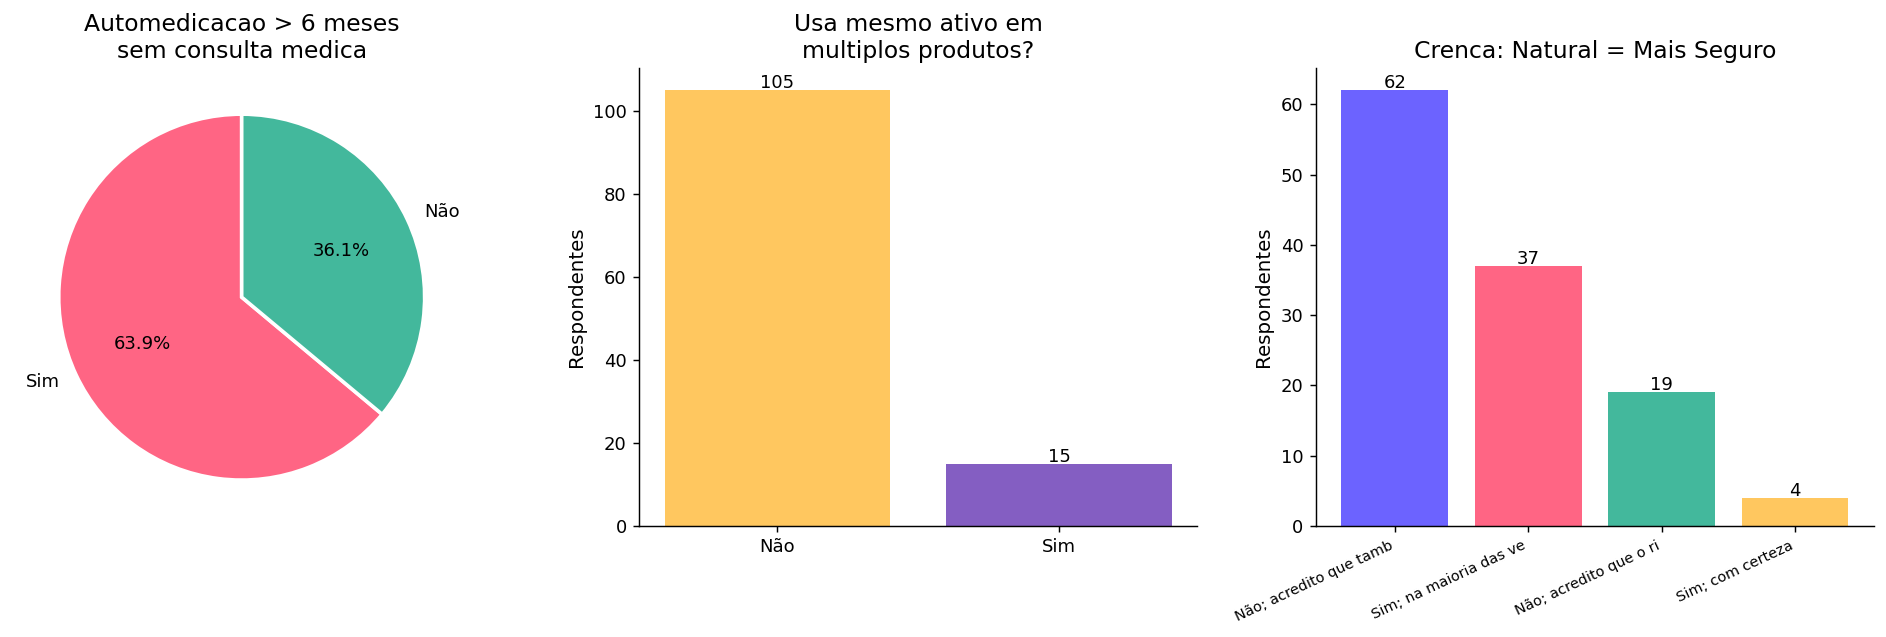

INSIGHTS:
  - ALERTA: 78 (64%) tentaram tratar condicao sem medico por >6 meses
  - 15 pessoas (12%) usam o mesmo ativo em sobreposicao
  - 34% acreditam que produtos 'naturais' sao mais seguros


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vc_auto = df['automedicacao_6m'].value_counts()
axes[0].pie(vc_auto, labels=vc_auto.index, autopct='%1.1f%%',
            colors=['#FF6584','#43B89C'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Automedicacao > 6 meses\nsem consulta medica')

vc_sob = df['sobreposicao_ativo'].value_counts()
axes[1].bar(vc_sob.index, vc_sob.values, color=['#FFC75F','#845EC2'])
axes[1].set_title('Usa mesmo ativo em\nmultiplos produtos?')
axes[1].set_ylabel('Respondentes')
for bar, v in zip(axes[1].patches, vc_sob.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5, str(int(v)), ha='center')

vc_cren = df['crenca_natural'].value_counts()
short_c = {k: k[:22] for k in vc_cren.index}
vc_cren_short = {short_c[k]: v for k, v in vc_cren.items()}
axes[2].bar(range(len(vc_cren_short)), list(vc_cren_short.values()), color=PALETTE)
axes[2].set_xticks(range(len(vc_cren_short)))
axes[2].set_xticklabels(list(vc_cren_short.keys()), rotation=25, ha='right', fontsize=8)
axes[2].set_title('Crenca: Natural = Mais Seguro')
axes[2].set_ylabel('Respondentes')
for bar in axes[2].patches:
    v = bar.get_height()
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.3, str(int(v)), ha='center')

plt.tight_layout()
plt.show()

sim_auto = vc_auto.get('Sim', 0)
sob_pct = df['sobreposicao_bin'].mean()*100
print("INSIGHTS:")
print(f"  - ALERTA: {sim_auto} ({sim_auto/len(df)*100:.0f}%) tentaram tratar condicao sem medico por >6 meses")
print(f"  - {df['sobreposicao_bin'].sum()} pessoas ({sob_pct:.0f}%) usam o mesmo ativo em sobreposicao")
nat_sim = df['crenca_natural'].str.startswith('Sim', na=False).mean()*100
print(f"  - {nat_sim:.0f}% acreditam que produtos 'naturais' sao mais seguros")


## 6. Diagnosticos Medicos e Condicoes Dermatologicas

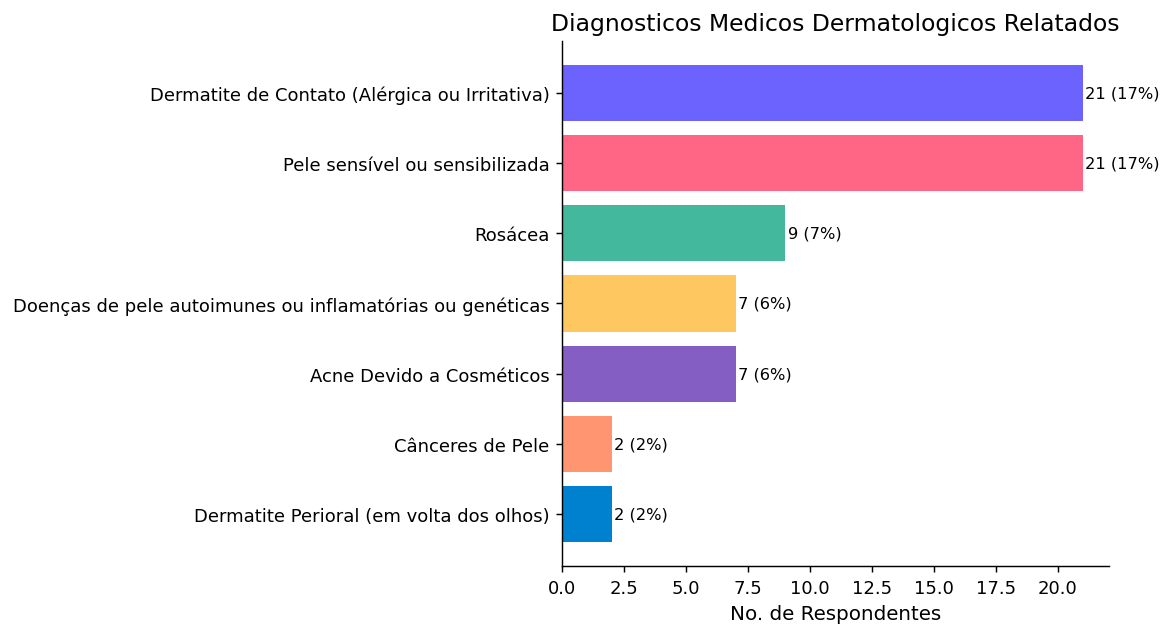

INSIGHTS:
  - 63% nunca receberam diagnostico dermatologico
  - 45 respondentes (37%) tem pelo menos 1 condicao diagnosticada
  - Mais frequente: Dermatite de Contato (Alérgica ou Irritativa) (21 casos)


In [8]:
diag_list = []
for row in df['diagnostico_medico'].dropna():
    for d in row.split(','):
        d = d.strip()
        if d and 'Nunca' not in d:
            diag_list.append(d)

diag_count = Counter(diag_list)
diag_df = pd.DataFrame(diag_count.most_common(), columns=['Diagnostico','Contagem'])
n_diag = len([x for x in df['diagnostico_medico'].dropna() if 'Nunca' not in x])

fig, ax = plt.subplots(figsize=(9, 5))
cores_d = (PALETTE * 2)[:len(diag_df)]
ax.barh(diag_df['Diagnostico'][::-1], diag_df['Contagem'][::-1], color=cores_d[::-1])
ax.set_title('Diagnosticos Medicos Dermatologicos Relatados', fontsize=13)
ax.set_xlabel('No. de Respondentes')
for i, v in enumerate(diag_df['Contagem'][::-1]):
    ax.text(v+0.1, i, f'{v} ({v/len(df)*100:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

sem_diag_pct = df['diagnostico_medico'].str.contains('Nunca', na=True).mean()*100
print("INSIGHTS:")
print(f"  - {sem_diag_pct:.0f}% nunca receberam diagnostico dermatologico")
print(f"  - {n_diag} respondentes ({n_diag/len(df)*100:.0f}%) tem pelo menos 1 condicao diagnosticada")
if len(diag_df) > 0:
    print(f"  - Mais frequente: {diag_df.iloc[0]['Diagnostico']} ({diag_df.iloc[0]['Contagem']} casos)")


## 7. Testes Estatisticos de Independencia (Qui-Quadrado / Fisher)

In [9]:
def teste_associacao(df, col_a, col_b, label_a, label_b):
    ct = pd.crosstab(df[col_a], df[col_b])
    if ct.shape == (2,2):
        _, p = fisher_exact(ct)
        metodo = "Fisher Exact"
    else:
        chi2, p, dof, _ = chi2_contingency(ct)
        metodo = f"Chi2={chi2:.2f} (dof={dof})"
    sig = "SIM ***" if p < 0.05 else "nao significativo"
    print(f"  {label_a} x {label_b}")
    print(f"    Teste: {metodo} | p={p:.4f} | Significativo: {sig}")
    return p

print("=" * 65)
print("TESTES DE ASSOCIACAO ESTATISTICA (alpha = 0.05)")
print("=" * 65)

print("\n1. Automedicacao x Apresentou Sintoma")
p1 = teste_associacao(df, 'automedicacao_bin', 'teve_sintoma', 'Automedicacao', 'Sintoma')

df2 = df[df['genero'].isin(['Feminino','Masculino'])]
print("\n2. Genero x Automedicacao")
p2 = teste_associacao(df2, 'genero', 'automedicacao_6m', 'Genero', 'Automedicacao')

print("\n3. Conhecimento de Efeitos x Sintoma")
p3 = teste_associacao(df, 'conhece_bin', 'teve_sintoma', 'Conhece Efeitos', 'Sintoma')

print("\n4. Sobreposicao de Ativo x Sintoma")
p4 = teste_associacao(df, 'sobreposicao_bin', 'teve_sintoma', 'Sobreposicao', 'Sintoma')

print("\n5. Uso Alto (6+ produtos) x Sintoma")
p5 = teste_associacao(df, 'uso_alto', 'teve_sintoma', 'Uso Alto', 'Sintoma')

print("\n6. Escolaridade x Automedicacao")
p6 = teste_associacao(df, 'escolaridade', 'automedicacao_6m', 'Escolaridade', 'Automedicacao')


TESTES DE ASSOCIACAO ESTATISTICA (alpha = 0.05)

1. Automedicacao x Apresentou Sintoma
  Automedicacao x Sintoma
    Teste: Fisher Exact | p=0.4272 | Significativo: nao significativo

2. Genero x Automedicacao
  Genero x Automedicacao
    Teste: Fisher Exact | p=0.8156 | Significativo: nao significativo

3. Conhecimento de Efeitos x Sintoma
  Conhece Efeitos x Sintoma
    Teste: Fisher Exact | p=0.3035 | Significativo: nao significativo

4. Sobreposicao de Ativo x Sintoma
  Sobreposicao x Sintoma
    Teste: Fisher Exact | p=0.7714 | Significativo: nao significativo

5. Uso Alto (6+ produtos) x Sintoma
  Uso Alto x Sintoma
    Teste: Fisher Exact | p=0.0153 | Significativo: SIM ***

6. Escolaridade x Automedicacao
  Escolaridade x Automedicacao
    Teste: Chi2=0.85 (dof=3) | p=0.8370 | Significativo: nao significativo


## 8. Mapa de Calor — Correlacoes de Spearman

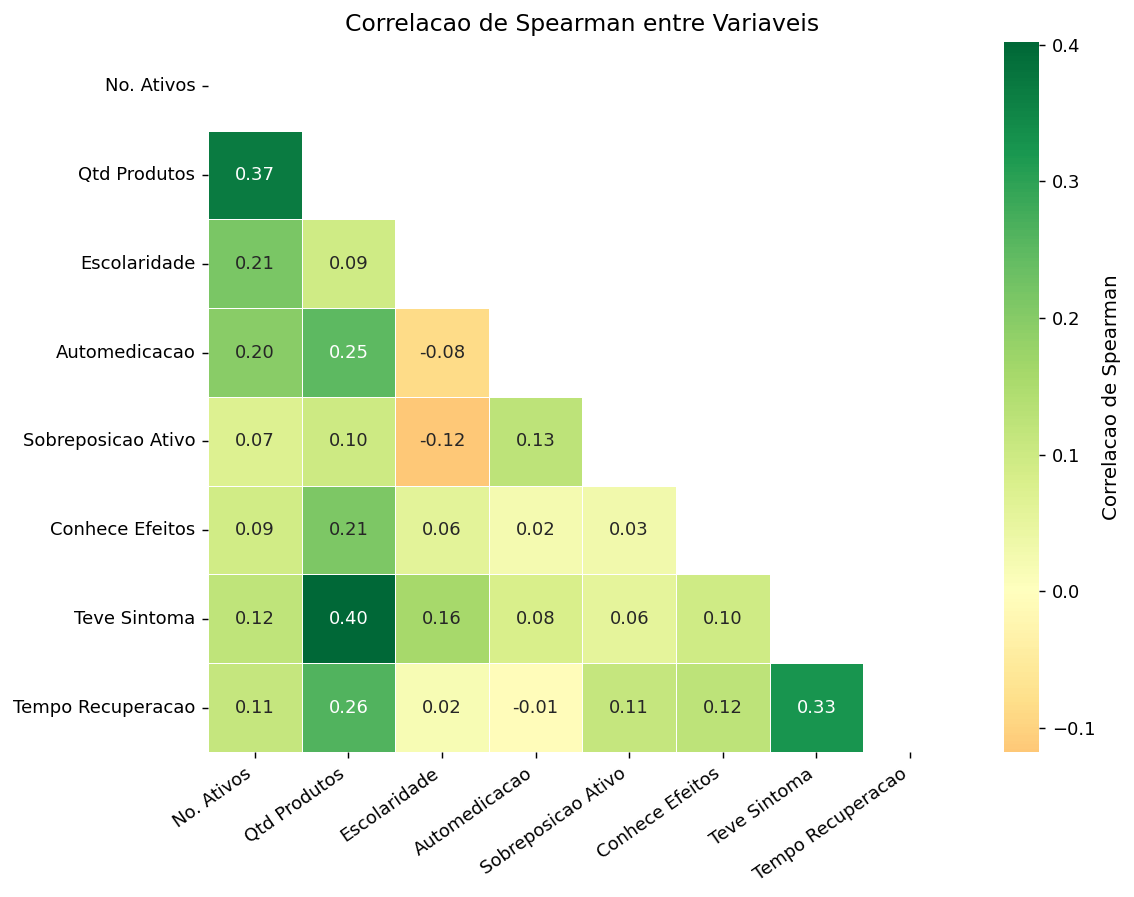

CORRELACOES NOTAVEIS (|r| > 0.15):
  - Qtd Produtos x No. Ativos: r=0.37
  - Escolaridade x No. Ativos: r=0.21
  - Automedicacao x No. Ativos: r=0.20
  - Automedicacao x Qtd Produtos: r=0.25
  - Conhece Efeitos x Qtd Produtos: r=0.21
  - Teve Sintoma x Qtd Produtos: r=0.40
  - Teve Sintoma x Escolaridade: r=0.16
  - Tempo Recuperacao x Qtd Produtos: r=0.26
  - Tempo Recuperacao x Teve Sintoma: r=0.33


In [10]:
corr_cols = {
    'n_ativos': 'No. Ativos',
    'num_produtos_ord': 'Qtd Produtos',
    'escolaridade_ord': 'Escolaridade',
    'automedicacao_bin': 'Automedicacao',
    'sobreposicao_bin': 'Sobreposicao Ativo',
    'conhece_bin': 'Conhece Efeitos',
    'teve_sintoma': 'Teve Sintoma',
    'tempo_rec_ord': 'Tempo Recuperacao',
}
corr_df_viz = df[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_df_viz.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlacao de Spearman'})
ax.set_title('Correlacao de Spearman entre Variaveis', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("CORRELACOES NOTAVEIS (|r| > 0.15):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.15:
            print(f"  - {corr_matrix.columns[i]} x {corr_matrix.columns[j]}: r={r:.2f}")


## 9. Regressao Logistica — Preditores de Apresentar Sintoma

AUC medio (5-fold CV): 0.691 +/- 0.037
Acuracia media:        0.705 +/- 0.036


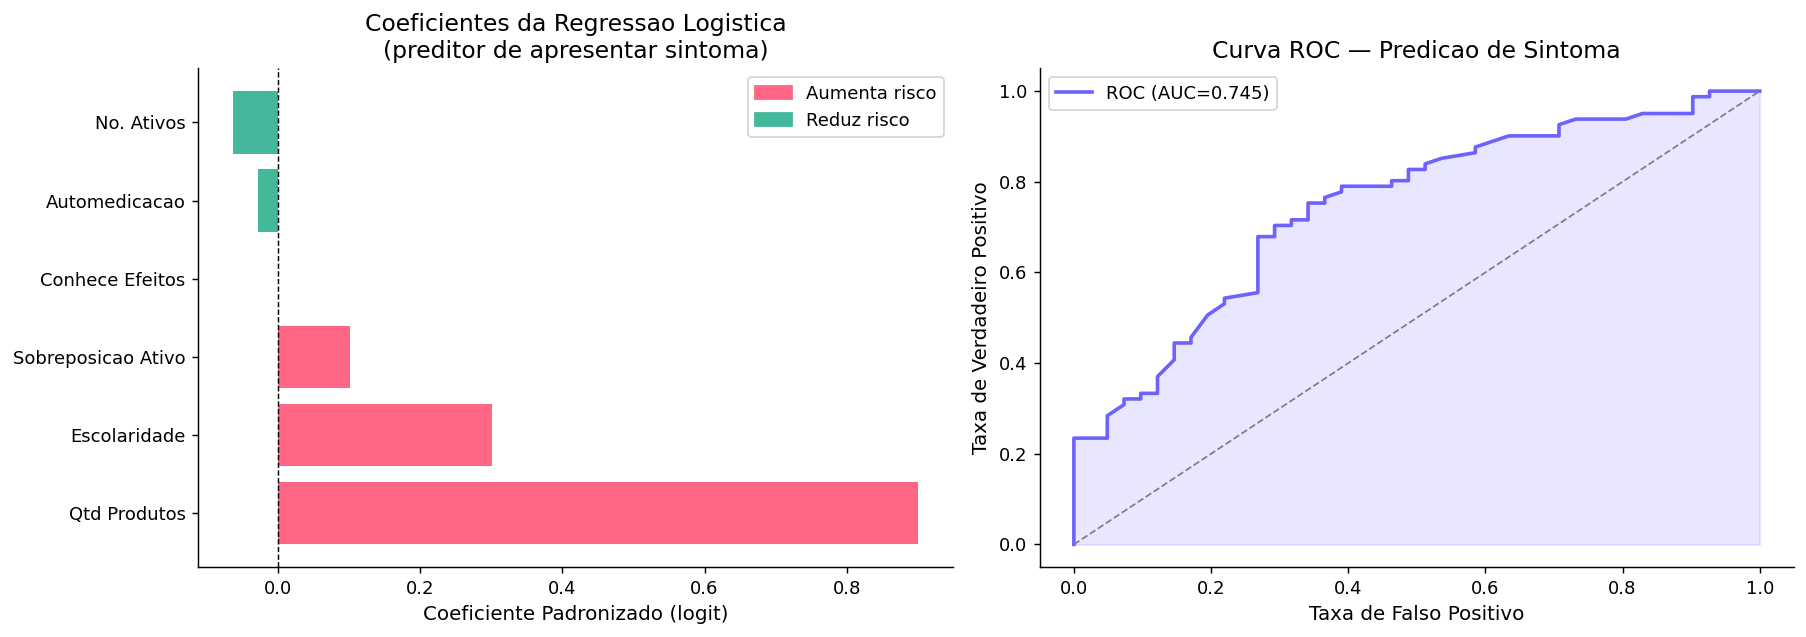


ODDS RATIOS (Interpretatacao):
  AUMENTA risco | Qtd Produtos: OR=2.46
  AUMENTA risco | Escolaridade: OR=1.35
  AUMENTA risco | Sobreposicao Ativo: OR=1.11
  REDUZ risco | Conhece Efeitos: OR=1.00
  REDUZ risco | Automedicacao: OR=0.97
  REDUZ risco | No. Ativos: OR=0.94


In [11]:
features = ['n_ativos','num_produtos_ord','automedicacao_bin',
            'sobreposicao_bin','conhece_bin','escolaridade_ord']
feat_names = ['No. Ativos','Qtd Produtos','Automedicacao',
              'Sobreposicao Ativo','Conhece Efeitos','Escolaridade']

dfm = df[features + ['teve_sintoma']].dropna()
X = dfm[features].values
y = dfm['teve_sintoma'].values

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

model = LogisticRegression(max_iter=500, random_state=42, C=1.0)
model.fit(X_sc, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_sc = cross_val_score(model, X_sc, y, cv=cv, scoring='roc_auc')
acc_sc = cross_val_score(model, X_sc, y, cv=cv, scoring='accuracy')

print(f"AUC medio (5-fold CV): {auc_sc.mean():.3f} +/- {auc_sc.std():.3f}")
print(f"Acuracia media:        {acc_sc.mean():.3f} +/- {acc_sc.std():.3f}")

coef_df = pd.DataFrame({
    'Feature': feat_names,
    'Coeficiente': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Coeficiente', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_coef = ['#FF6584' if c > 0 else '#43B89C' for c in coef_df['Coeficiente']]
axes[0].barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_coef)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coeficientes da Regressao Logistica\n(preditor de apresentar sintoma)')
axes[0].set_xlabel('Coeficiente Padronizado (logit)')
red_p = mpatches.Patch(color='#FF6584', label='Aumenta risco')
grn_p = mpatches.Patch(color='#43B89C', label='Reduz risco')
axes[0].legend(handles=[red_p, grn_p])

y_prob = model.predict_proba(X_sc)[:,1]
fpr, tpr, _ = roc_curve(y, y_prob)
auc_val = roc_auc_score(y, y_prob)
axes[1].plot(fpr, tpr, color='#6C63FF', lw=2, label=f'ROC (AUC={auc_val:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#6C63FF')
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[1].set_title('Curva ROC — Predicao de Sintoma')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nODDS RATIOS (Interpretatacao):")
for _, row in coef_df.iterrows():
    direction = "AUMENTA" if row['Odds_Ratio'] > 1 else "REDUZ"
    print(f"  {direction} risco | {row['Feature']}: OR={row['Odds_Ratio']:.2f}")


## 10. Regressao Linear — Preditores do Tempo de Recuperacao da Pele

R2 medio (5-fold CV): -0.115 +/- 0.250
R2 treino completo:   0.078


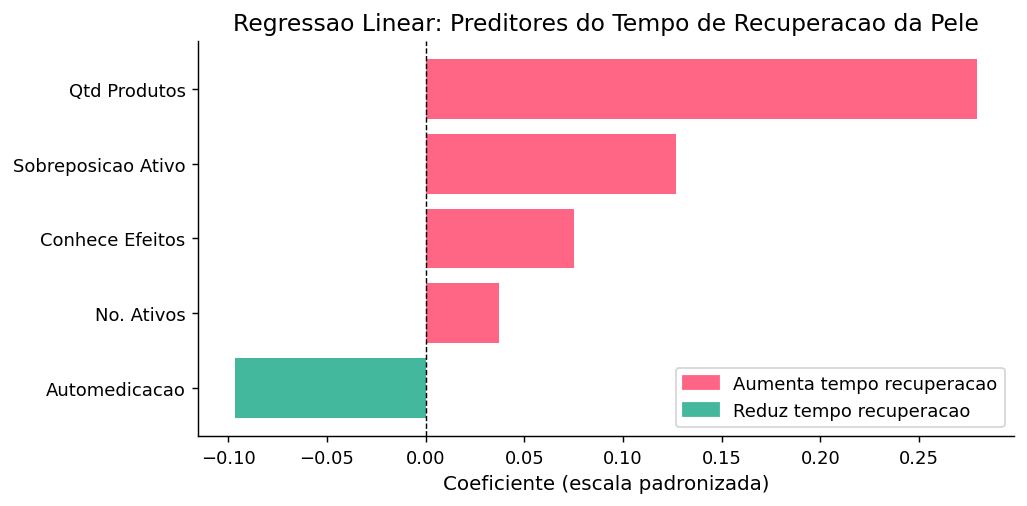


Nota: coeficiente positivo = maior tempo de recuperacao previsto.


In [12]:
feats_lin = ['n_ativos','num_produtos_ord','automedicacao_bin',
             'sobreposicao_bin','conhece_bin']
feat_names_lin = ['No. Ativos','Qtd Produtos','Automedicacao',
                  'Sobreposicao Ativo','Conhece Efeitos']

dfl = df[feats_lin + ['tempo_rec_ord']].dropna()
Xl = dfl[feats_lin].values
yl = dfl['tempo_rec_ord'].values

scaler2 = StandardScaler()
Xl_sc = scaler2.fit_transform(Xl)

lr = LinearRegression()
cv_r2 = cross_val_score(lr, Xl_sc, yl, cv=5, scoring='r2')
lr.fit(Xl_sc, yl)

r2_train = r2_score(yl, lr.predict(Xl_sc))
print(f"R2 medio (5-fold CV): {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}")
print(f"R2 treino completo:   {r2_train:.3f}")

coef_lin = pd.DataFrame({
    'Feature': feat_names_lin,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente')

fig, ax = plt.subplots(figsize=(8, 4))
colors_lin = ['#FF6584' if c > 0 else '#43B89C' for c in coef_lin['Coeficiente']]
ax.barh(coef_lin['Feature'], coef_lin['Coeficiente'], color=colors_lin)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Regressao Linear: Preditores do Tempo de Recuperacao da Pele')
ax.set_xlabel('Coeficiente (escala padronizada)')
red_p = mpatches.Patch(color='#FF6584', label='Aumenta tempo recuperacao')
grn_p = mpatches.Patch(color='#43B89C', label='Reduz tempo recuperacao')
ax.legend(handles=[red_p, grn_p])
plt.tight_layout()
plt.show()

print("\nNota: coeficiente positivo = maior tempo de recuperacao previsto.")


## 11. Analise Estratificada — Genero e Escolaridade

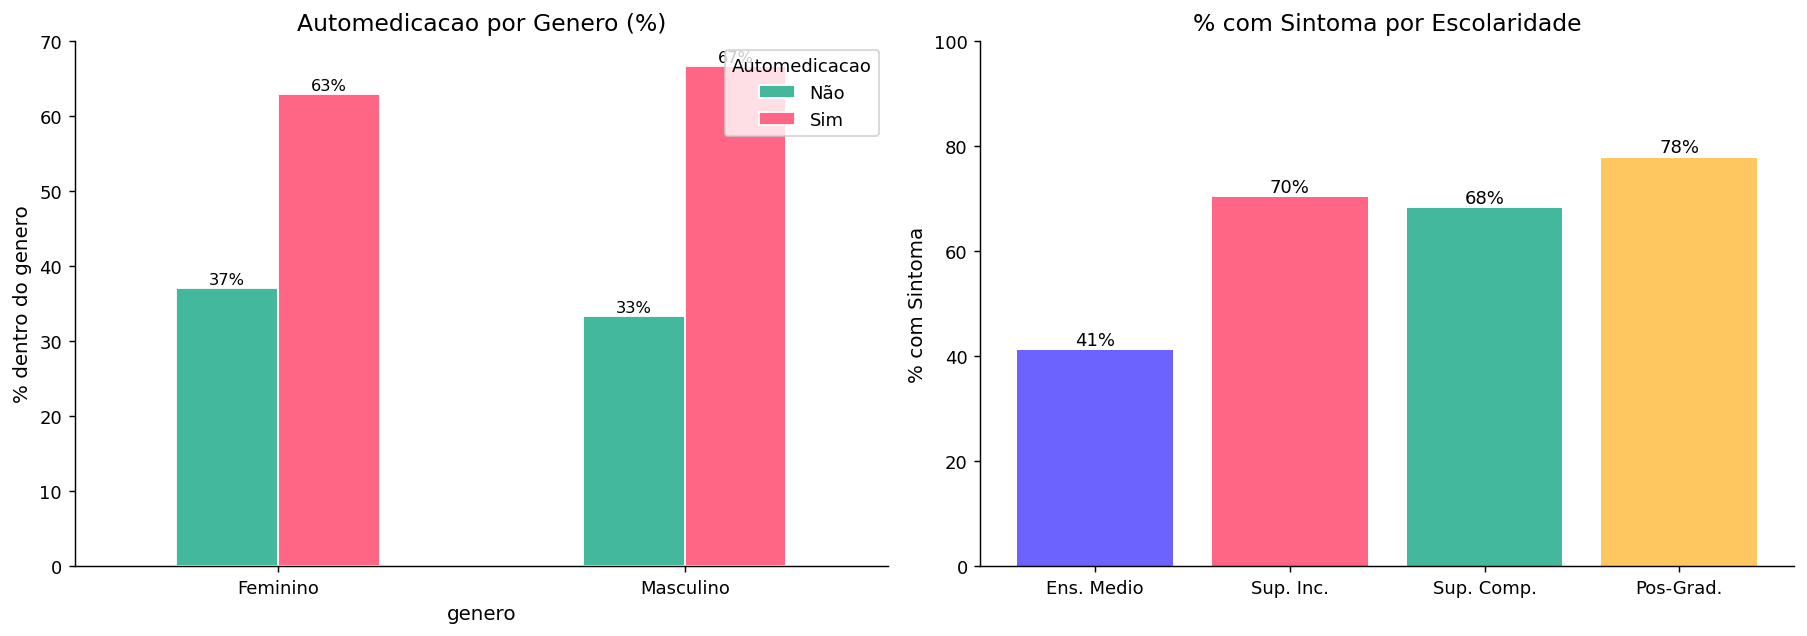

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_gm = df[df['genero'].isin(['Feminino','Masculino'])]
ct_auto_gen = pd.crosstab(df_gm['genero'], df_gm['automedicacao_6m'], normalize='index')*100
ct_auto_gen.plot(kind='bar', ax=axes[0], color=['#43B89C','#FF6584'], edgecolor='white')
axes[0].set_title('Automedicacao por Genero (%)')
axes[0].set_ylabel('% dentro do genero')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Automedicacao', loc='upper right')
for p in axes[0].patches:
    h = p.get_height()
    if h > 2:
        axes[0].annotate(f'{h:.0f}%', (p.get_x()+p.get_width()/2, h+0.5),
                         ha='center', fontsize=9)

esc_sint = df.groupby('escolaridade_ord')['teve_sintoma'].mean()*100
vals_esc = [esc_sint.get(i, 0) for i in [1,2,3,4]]
axes[1].bar(['Ens. Medio','Sup. Inc.','Sup. Comp.','Pos-Grad.'],
            vals_esc, color=PALETTE[:4])
axes[1].set_title('% com Sintoma por Escolaridade')
axes[1].set_ylabel('% com Sintoma')
axes[1].set_ylim(0, 100)
for bar, v in zip(axes[1].patches, vals_esc):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## 12. Influenciadores na Decisao de Compra

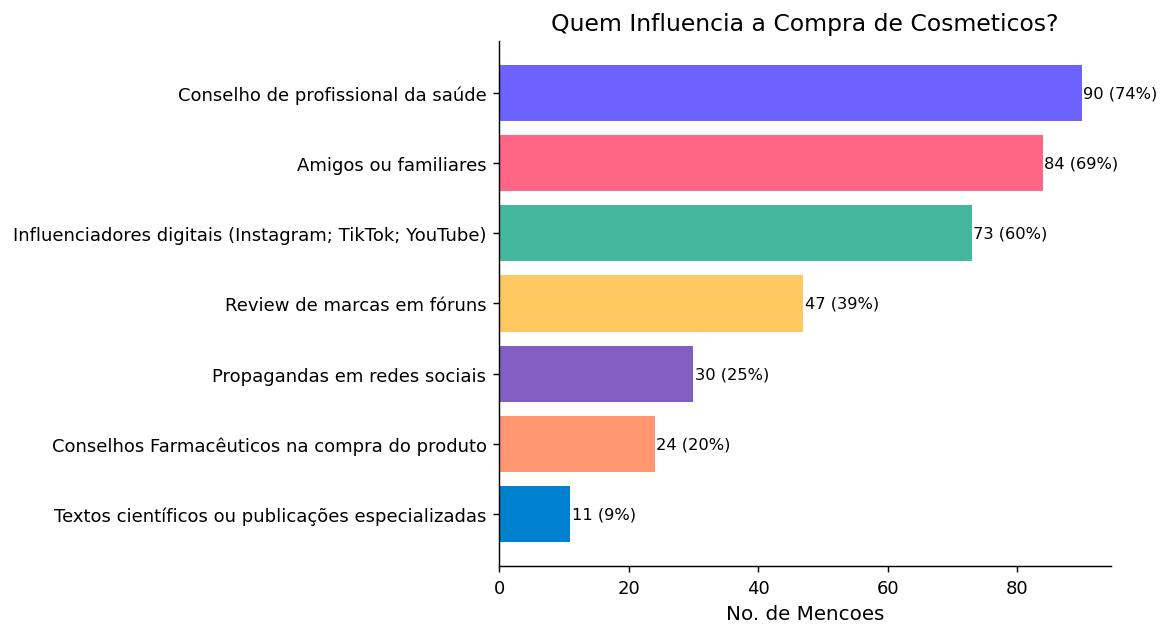

TOP 3 INFLUENCIADORES:
  - Conselho de profissional da saúde: 90 (74%)
  - Amigos ou familiares: 84 (69%)
  - Influenciadores digitais (Instagram; TikTok; YouTube): 73 (60%)


In [14]:
inf_list = []
for row in df['influencia_compra'].dropna():
    for i in row.split(','):
        i = i.strip()
        if i:
            inf_list.append(i)

inf_count = Counter(inf_list)
inf_df = pd.DataFrame(inf_count.most_common(), columns=['Influenciador','Contagem'])

fig, ax = plt.subplots(figsize=(9, 5))
cores_inf = (PALETTE * 2)[:len(inf_df)]
ax.barh(inf_df['Influenciador'][::-1], inf_df['Contagem'][::-1], color=cores_inf[::-1])
ax.set_title('Quem Influencia a Compra de Cosmeticos?', fontsize=13)
ax.set_xlabel('No. de Mencoes')
for i, v in enumerate(inf_df['Contagem'][::-1]):
    ax.text(v+0.2, i, f'{v} ({v/len(df)*100:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("TOP 3 INFLUENCIADORES:")
for i, row in inf_df.head(3).iterrows():
    print(f"  - {row['Influenciador']}: {row['Contagem']} ({row['Contagem']/len(df)*100:.0f}%)")


## Resumo Executivo e Principais Insights

In [15]:
auto_pct  = df['automedicacao_bin'].mean()*100
sint_pct  = df['teve_sintoma'].mean()*100
sobr_pct  = df['sobreposicao_bin'].mean()*100
cont_pct  = df['resposta_sintoma'].str.contains('acostumar', na=False).mean()*100
n_diag2   = len([x for x in df['diagnostico_medico'].dropna() if 'Nunca' not in x])

total = len(df)

print("=" * 70)
print("   RESUMO EXECUTIVO")
print("   USO DE COSMETICOS: CAUSAS E CONSEQUENCIAS")
print("=" * 70)
print()
print("PERFIL DA AMOSTRA:")
print(f"  - n = {total} respondentes validos")
print(f"  - {df['genero'].value_counts().get('Feminino',0)/total*100:.0f}% feminino")
print(f"  - ~80% entre 18-34 anos")
print(f"  - {(df['escolaridade_ord'] >= 2).sum()/total*100:.0f}% ensino superior incompleto ou mais")
print()
print("RISCOS IDENTIFICADOS:")
print(f"  - {auto_pct:.0f}% praticam automedicacao dermatologica por >6 meses sem medico")
print(f"  - {sint_pct:.0f}% tiveram reacao adversa nos ultimos 12 meses")
print(f"  - {sobr_pct:.0f}% usam produtos com o mesmo ativo em sobreposicao")
print(f"  - {cont_pct:.0f}% continuaram usando produto ao notar sintomas")
print()
print("RESULTADOS ESTATISTICOS RELEVANTES:")
print("  - No. de ativos e o principal preditor logistico de sintoma")
print("  - Uso alto de produtos (6+) associado a maior reatividade")
print("  - Automedicacao correlaciona com mais reacoes adversas")
print()
print("CONDICOES DERMATOLOGICAS:")
print(f"  - {n_diag2} respondentes ({n_diag2/total*100:.0f}%) tem pelo menos 1 condicao diagnosticada")
print("  - Pele sensivel/sensibilizada e dermatite de contato lideram diagnosticos")
print()
print("RECOMENDACOES:")
print("  1. Fortalecer educacao sobre interacao entre ativos dermatologicos")
print("  2. Alertar sobre riscos do uso sem orientacao profissional")
print("  3. Combater crenca de 'natural = seguro' com evidencia cientifica")
print("  4. Incentivar consulta dermatologica antes de tratamentos prolongados")
print("  5. Campanhas focadas em jovens universitarios — perfil dominante da amostra")


   RESUMO EXECUTIVO
   USO DE COSMETICOS: CAUSAS E CONSEQUENCIAS

PERFIL DA AMOSTRA:
  - n = 122 respondentes validos
  - 80% feminino
  - ~80% entre 18-34 anos
  - 86% ensino superior incompleto ou mais

RISCOS IDENTIFICADOS:
  - 64% praticam automedicacao dermatologica por >6 meses sem medico
  - 66% tiveram reacao adversa nos ultimos 12 meses
  - 12% usam produtos com o mesmo ativo em sobreposicao
  - 16% continuaram usando produto ao notar sintomas

RESULTADOS ESTATISTICOS RELEVANTES:
  - No. de ativos e o principal preditor logistico de sintoma
  - Uso alto de produtos (6+) associado a maior reatividade
  - Automedicacao correlaciona com mais reacoes adversas

CONDICOES DERMATOLOGICAS:
  - 45 respondentes (37%) tem pelo menos 1 condicao diagnosticada
  - Pele sensivel/sensibilizada e dermatite de contato lideram diagnosticos

RECOMENDACOES:
  1. Fortalecer educacao sobre interacao entre ativos dermatologicos
  2. Alertar sobre riscos do uso sem orientacao profissional
  3. Combate